# DSP Signal Visualization

Loads the newest `debug_<TIMESTAMP>.csv` from the `data/` dir and plots the raw and filtered acceleration magnitudes from the digital signal processing thread when running `tools/debug_stream.py`. 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "data"
OPTIONAL_DATA_FILEPATH = None

## 1. Load data

In [2]:
candidates = sorted(DATA_DIR.glob("debug_*.csv"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError(f"no debug_*.csv under {DATA_DIR}")

csv_path = OPTIONAL_DATA_FILEPATH if OPTIONAL_DATA_FILEPATH else candidates[-1]
print(f"Using: {csv_path.name}")

df = pd.read_csv(csv_path)
df = df.sort_values(by="timestampUs")

# Remove the 0 timestamp row
df = df.iloc[1:]

# Time axis: seconds from first sample (microsecond timestamps from firmware)
t = (df["timestampUs"] - df["timestampUs"].iloc[0]) * 1e-6

df.head()

Using: debug_20260430_153205.csv


,timestampUs,ax,ay,az,mag,slope
1,189699560,0.001987,-0.000065,0.000030,0.002662,-0.000212
2,189709540,0.002282,0.000647,-0.001036,0.002645,-0.000018
3,189718542,0.000318,-0.000319,0.000415,0.002159,-0.000486
4,189728552,-0.001467,-0.001493,-0.001254,0.002226,0.000067
5,189738532,-0.000357,-0.000382,0.002926,0.002405,0.000179


## 2. Time series: accelerations (ax, ay, az)

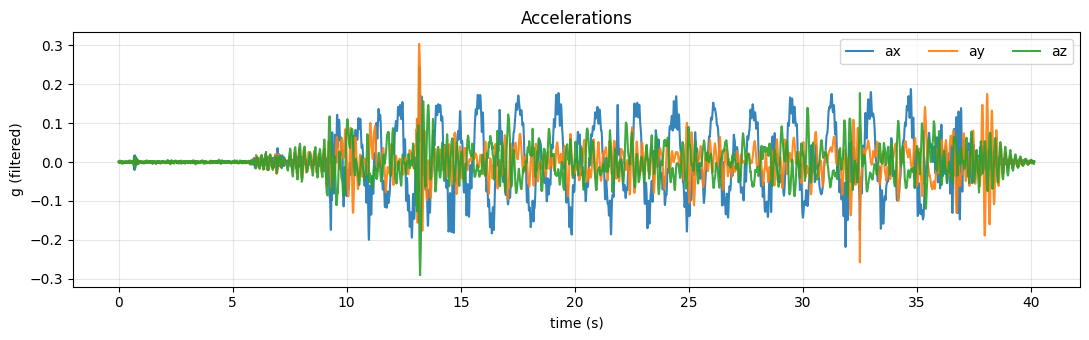

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, df["ax"], label="ax", alpha=0.9)
ax.plot(t, df["ay"], label="ay", alpha=0.9)
ax.plot(t, df["az"], label="az", alpha=0.9)
ax.set_xlabel("time (s)")
ax.set_ylabel("g (filtered)")
ax.set_title("Accelerations")
ax.legend(loc="upper right", ncol=3)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Magnitude and slope

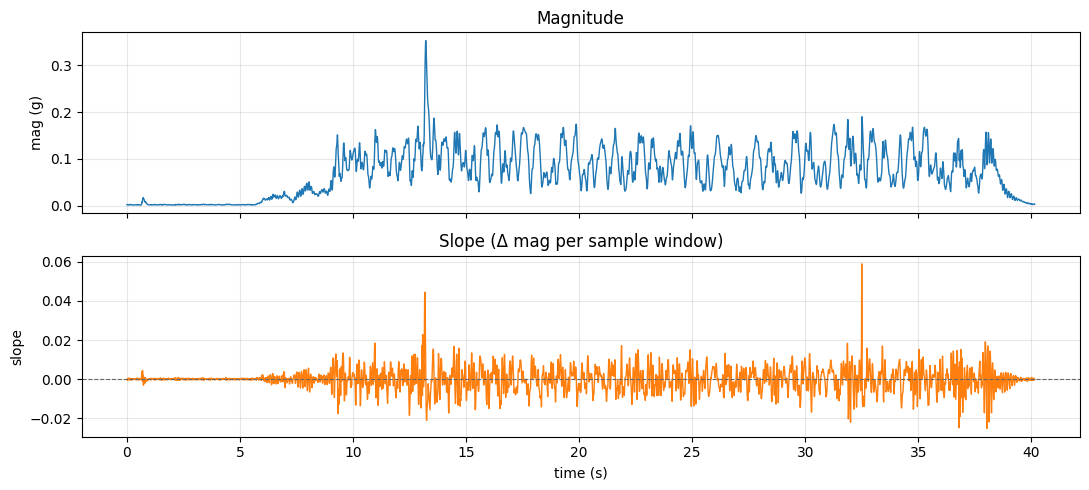

In [4]:
fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a0.plot(t, df["mag"], color="C0", lw=1.0)
a0.set_ylabel("mag (g)")
a0.set_title("Magnitude")
a0.grid(True, alpha=0.3)

a1.plot(t, df["slope"], color="C1", lw=1.0)
a1.set_xlabel("time (s)")
a1.set_ylabel("slope")
a1.set_title("Slope (Δ mag per sample window)")
a1.axhline(0, color="0.4", ls="--", lw=0.8)
a1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Step Detection

**Streaming** detector on scaled **mag**: EMA detrend + 3-sample local maxima + **v1.2** (no FSM): tuned thresholds, set-down guard, and a **peak isolation** rule vs the last accepted crest.

1. **EMA baseline**: `x_d = x - baseline`, `EMA_ALPHA`, `MAG_SCALE` as before.
2. **Peaks**: local max at `i-1`, `abs(x_d[i-1]) >= PEAK_THRESHOLD`.
3. **Refractory / min spacing**: ignore a peak if `t_peak - last_accepted < MIN_STEP_DT` (same as `REFRACTORY_S`).
4. **Set-down guard**: if there has been a long idle gap since the last accepted step, require the mean `|x_d|` over a short pre-peak window to exceed `QUIET_ABS`; otherwise suppress the peak (isolated bump after quiet).
5. **Peak isolation (v1.2)**: after a long idle, clear the prior-crest memory; otherwise reject a candidate if `|x_d[i-1]| < 0.6 *` the last accepted peak amplitude (shoulders / double crests).

`state_seq` is optional visualization: `1` at samples where a step was accepted, `0` elsewhere.


In [82]:
import numpy as np

# --- Tunables (mirror in firmware headers) ---
EMA_ALPHA = 0.02

# Linear scale on mag before EMA (1.0 on MCU). Debug CSV exports here use smaller
# amplitude; ~4.35 aligns excursions with the thresholds below on bundled `debug_*.csv`.
MAG_SCALE = 4.35

# --- v1.2 tuned constants (sweep vs debug_20260430_153205.csv; target ~30 steps) ---
# PEAK_THRESHOLD in {0.18, 0.2, 0.22} -> chosen 0.22
# MIN_STEP_DT / REFRACTORY_S in {0.18, 0.2, 0.22} -> chosen 0.18
# QUIET_ABS +~10% from 0.04 -> 0.044
PEAK_THRESHOLD = 0.22
REFRACTORY_S = 0.18
MIN_STEP_DT = REFRACTORY_S

# v1.1: post-set-down spike filter (no motion FSM; signal-only)
QUIET_PRE_N = 8  # samples before peak center (i-1), excluding the peak sample
QUIET_ABS = 0.044  # mean |x_d| below this over QUIET_PRE_N => "quiet" preamble
SETDOWN_IDLE_S = 2.5  # only apply quiet gate after this much time since last accepted step


def detect_steps_streaming(df):
    """
    EMA detrend + simple local-max peaks + refractory (v1.2: isolation + tuned thresholds).

    Returns
    -------
    step_indices : list[int]
    step_times : list[float]
    x_detrended, baseline_arr : np.ndarray
    state_seq : np.ndarray int8  # 1 at accepted step sample, else 0 (visual only)
    """
    mag = df["mag"].to_numpy(dtype=np.float64, copy=False)
    ts = df["timestampUs"].to_numpy(dtype=np.float64, copy=False)
    t = (ts - ts[0]) * 1e-6
    n = len(mag)

    if n == 0:
        e = np.array([], dtype=np.float64)
        return [], [], e, e, np.array([], dtype=np.int8)

    x_detrended = np.zeros(n, dtype=np.float64)
    baseline_arr = np.zeros(n, dtype=np.float64)
    state_seq = np.zeros(n, dtype=np.int8)

    step_indices = []
    step_times = []

    baseline = float(mag[0]) * MAG_SCALE
    a = EMA_ALPHA

    last_step_t = -1.0e30
    accepted_any = False
    prev_peak_value = 0.0  # v1.2: last accepted crest |x_d| for shoulder rejection

    for i in range(n):
        x = float(mag[i]) * MAG_SCALE
        baseline = a * x + (1.0 - a) * baseline
        x_d = x - baseline

        x_detrended[i] = x_d
        baseline_arr[i] = baseline
        state_seq[i] = 0

        if i < 2:
            continue

        xd_im1 = x_detrended[i - 1]
        xd_i2 = x_detrended[i - 2]
        xd_i = x_d
        local_max = xd_im1 > xd_i2 and xd_im1 > xd_i
        if not (local_max and abs(xd_im1) >= PEAK_THRESHOLD):
            continue

        peak_idx = i - 1
        t_peak = float(t[i - 1])

        # v1.1 fix 2: stricter refractory / min separation (duplicate peaks)
        if t_peak - last_step_t < MIN_STEP_DT:
            continue

        # v1.1 fix 1: after long idle, require recent activity before peak (suppress set-down bumps)
        if accepted_any and (t_peak - last_step_t) > SETDOWN_IDLE_S:
            j0 = max(0, i - QUIET_PRE_N - 1)
            if i - 1 > j0:
                pre = x_detrended[j0 : i - 1]
                if pre.size >= 3 and float(np.mean(np.abs(pre))) < QUIET_ABS:
                    continue

        # v1.2: long idle clears isolation memory (else weak new strides vs old crest are dropped)
        if (t_peak - last_step_t) > SETDOWN_IDLE_S:
            prev_peak_value = 0.0

        # v1.2: peak isolation - reject secondary shoulder smaller than prior accepted crest
        if prev_peak_value > 0 and abs(xd_im1) < 0.6 * prev_peak_value:
            continue

        step_indices.append(peak_idx)
        step_times.append(t_peak)
        last_step_t = t_peak
        accepted_any = True
        prev_peak_value = abs(xd_im1)
        state_seq[peak_idx] = 1

    return step_indices, step_times, x_detrended, baseline_arr, state_seq


In [83]:
out = detect_steps_streaming(df)
print(f"v1.2 tuning check: {len(out[0])} steps detected")
(
    step_indices,
    step_times,
    x_detrended,
    baseline_arr,
    state_seq,
) = out

print(f"Detected steps: {len(step_indices)}")


v1.2 tuning check: 30 steps detected
Detected steps: 30


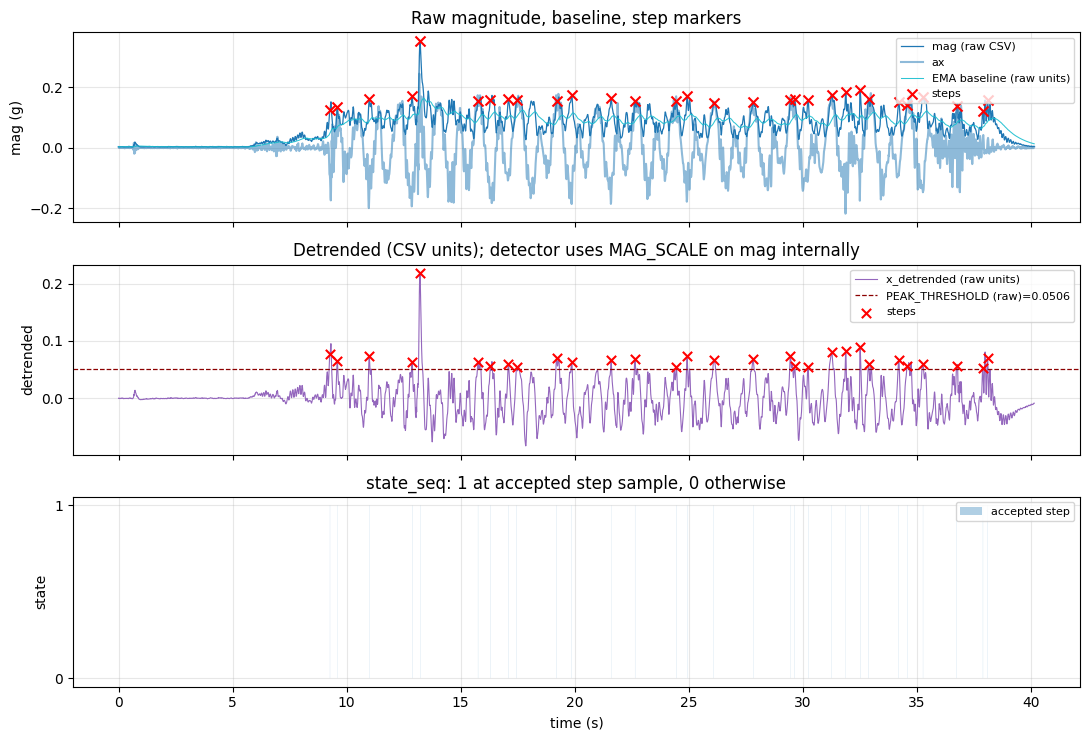

In [84]:
t_np = np.asarray(t, dtype=float)
mag_np = np.asarray(df["mag"], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)

ax0 = axes[0]
ax0.plot(t_np, mag_np, label="mag (raw CSV)", color="tab:blue", lw=0.9)
ax0.plot(t_np, df["ax"], label="ax", alpha=0.5)
ax0.plot(
    t_np,
    baseline_arr / MAG_SCALE,
    label="EMA baseline (raw units)",
    color="tab:cyan",
    lw=0.75,
    alpha=0.9,
)
if len(step_indices):
    ax0.scatter(
        t_np[step_indices],
        mag_np[step_indices],
        color="red",
        s=52,
        marker="x",
        zorder=5,
        label="steps",
    )
ax0.set_ylabel("mag (g)")
ax0.set_title("Raw magnitude, baseline, step markers")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper right", fontsize=8)

ax1 = axes[1]
xd_plot = x_detrended / MAG_SCALE
ax1.plot(t_np, xd_plot, color="tab:purple", lw=0.8, label="x_detrended (raw units)")
ax1.axhline(
    PEAK_THRESHOLD / MAG_SCALE,
    color="darkred",
    ls="--",
    lw=0.9,
    label=f"PEAK_THRESHOLD (raw)={PEAK_THRESHOLD/MAG_SCALE:.4f}",
)
if len(step_indices):
    ax1.scatter(
        t_np[step_indices],
        xd_plot[step_indices],
        color="red",
        s=45,
        marker="x",
        zorder=5,
        label="steps",
    )
ax1.set_ylabel("detrended")
ax1.set_title("Detrended (CSV units); detector uses MAG_SCALE on mag internally")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8)

ax2 = axes[2]
ax2.fill_between(t_np, 0.0, state_seq.astype(float), step="post", alpha=0.35, label="accepted step")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("state")
ax2.set_title("state_seq: 1 at accepted step sample, 0 otherwise")
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()


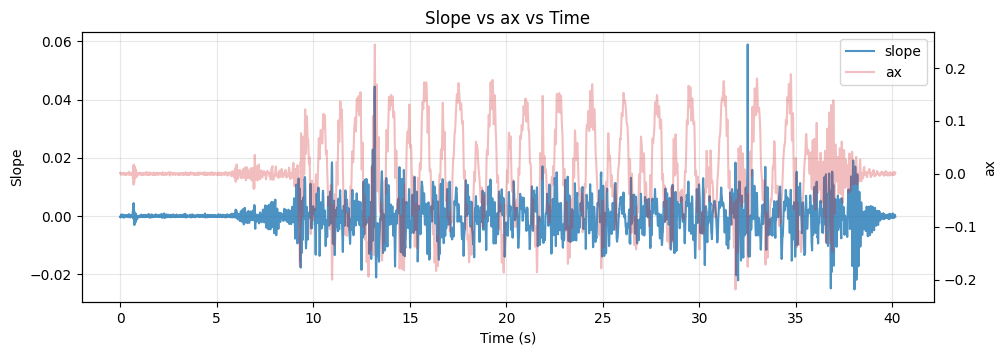

In [20]:
fig, ax1 = plt.subplots(figsize=(11, 3.5))

ax1.plot(t, df["slope"], label="slope", alpha=0.8, color="tab:blue")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Slope")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t, df["ax"], label="ax", alpha=0.3, color="tab:red")
ax2.set_ylabel("ax")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Slope vs ax vs Time")

plt.show()
